Metrics visualisation

# Libraries

In [1]:
import os
from pathlib import Path
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import pandas as pd

# Data load

In [2]:
df_metrics = pd.read_excel('../results/metrics_modelling2_highlight.xlsx')
df_metrics = df_metrics[
    df_metrics['dataset']=='df_modelling_dimensionless'].drop_duplicates()

## Splashing data

In [5]:
df_spalshing = df_metrics[df_metrics['target']=='splashing']
df_spalshing = df_spalshing.sort_values(by=['f1', 'roc_auc'], ascending=False).loc[
    [51, 59, 44, 43, 52]]
df_spalshing

,dataset,target,model,accuracy,f1,precision,recall,roc_auc
51,df_modelling_dimensionless,splashing,kneighborsclassifier_splashing_ordenc,0.866667,0.900000,0.865385,0.937500,0.839120
59,df_modelling_dimensionless,splashing,catboostclassifier_splashing,0.866667,0.900000,0.865385,0.937500,0.839120
44,df_modelling_dimensionless,splashing,svc_smote_splashing_onehot,0.853333,0.888889,0.862745,0.916667,0.828704
43,df_modelling_dimensionless,splashing,logisticregression_splashing_ordenc,0.813333,0.865385,0.803571,0.937500,0.765046
52,df_modelling_dimensionless,splashing,xgbclassifier_ohe_smote_splashing,0.840000,0.880000,0.846154,0.916667,0.810185


In [6]:
df_spalshing['model'] = df_spalshing['model'].apply(lambda x: x.split('_')[0])
df_spalshing = df_spalshing.iloc[: ,2:]
df_spalshing['model'] = df_spalshing['model'].map({
    'kneighborsclassifier': 'KNClassifier',
    'catboostclassifier': 'CatBoost',
    'svc': 'SVC',
    'logisticregression': 'Logistic Regression',
    'xgbclassifier': 'XGB-classifier'})
df_spalshing.rename(columns={'model': 'Model',
                             'accuracy': 'Accuracy',
                             'f1': 'F1',
                             'precision': 'Precision',
                             'recall': 'Recall',
                             'roc_auc': 'ROC AUC'}, inplace=True)
df_spalshing = df_spalshing.round(3)
df_spalshing['Target'] = 'Splashing'
df_spalshing

,Model,Accuracy,F1,Precision,Recall,ROC AUC,Target
51,KNClassifier,0.867,0.900,0.865,0.938,0.839,Splashing
59,CatBoost,0.867,0.900,0.865,0.938,0.839,Splashing
44,SVC,0.853,0.889,0.863,0.917,0.829,Splashing
43,Logistic Regression,0.813,0.865,0.804,0.938,0.765,Splashing
52,XGB-classifier,0.840,0.880,0.846,0.917,0.810,Splashing


## Net impact data

In [8]:
df_net_impact = df_metrics[df_metrics['target']=='net_impact']
df_net_impact = df_net_impact.sort_values(by=['f1', 'roc_auc'], ascending=False).loc[
    [22, 63, 100, 111, 104]]
df_net_impact

,dataset,target,model,accuracy,f1,precision,recall,roc_auc
22,df_modelling_dimensionless,net_impact,catboostclassifier_net_impact,0.946667,0.900000,0.900000,0.90,0.931818
63,df_modelling_dimensionless,net_impact,xgbclassifier_ohe_smote_net_impact,0.920000,0.842105,0.888889,0.80,0.881818
100,df_modelling_dimensionless,net_impact,logisticregression_net_impact_ordenc,0.893333,0.800000,0.800000,0.80,0.863636
111,df_modelling_dimensionless,net_impact,kneighborsclassifier_net_impact_onehot,0.880000,0.790698,0.739130,0.85,0.870455
104,df_modelling_dimensionless,net_impact,svc_smote_net_impact_onehot,0.880000,0.800000,0.720000,0.90,0.886364


In [9]:
df_net_impact['model'] = df_net_impact['model'].apply(lambda x: x.split('_')[0])
df_net_impact = df_net_impact.iloc[: ,2:]
df_net_impact['model'] = df_net_impact['model'].map({
    'kneighborsclassifier': 'KNClassifier',
    'catboostclassifier': 'CatBoost',
    'svc': 'SVC',
    'logisticregression': 'Logistic Regression',
    'xgbclassifier': 'XGB-classifier'})
df_net_impact.rename(columns={'model': 'Model',
                             'accuracy': 'Accuracy',
                             'f1': 'F1',
                             'precision': 'Precision',
                             'recall': 'Recall',
                             'roc_auc': 'ROC AUC'}, inplace=True)
df_net_impact = df_net_impact.round(3)
df_net_impact['Target'] = 'Net impact'
df_net_impact

,Model,Accuracy,F1,Precision,Recall,ROC AUC,Target
22,CatBoost,0.947,0.900,0.900,0.90,0.932,Net impact
63,XGB-classifier,0.920,0.842,0.889,0.80,0.882,Net impact
100,Logistic Regression,0.893,0.800,0.800,0.80,0.864,Net impact
111,KNClassifier,0.880,0.791,0.739,0.85,0.870,Net impact
104,SVC,0.880,0.800,0.720,0.90,0.886,Net impact


# Data plot

In [10]:
path_visualisations = Path('../results/metrics_visualisation/')
if not os.path.exists(path_visualisations): os.makedirs(path_visualisations)

## Net impact

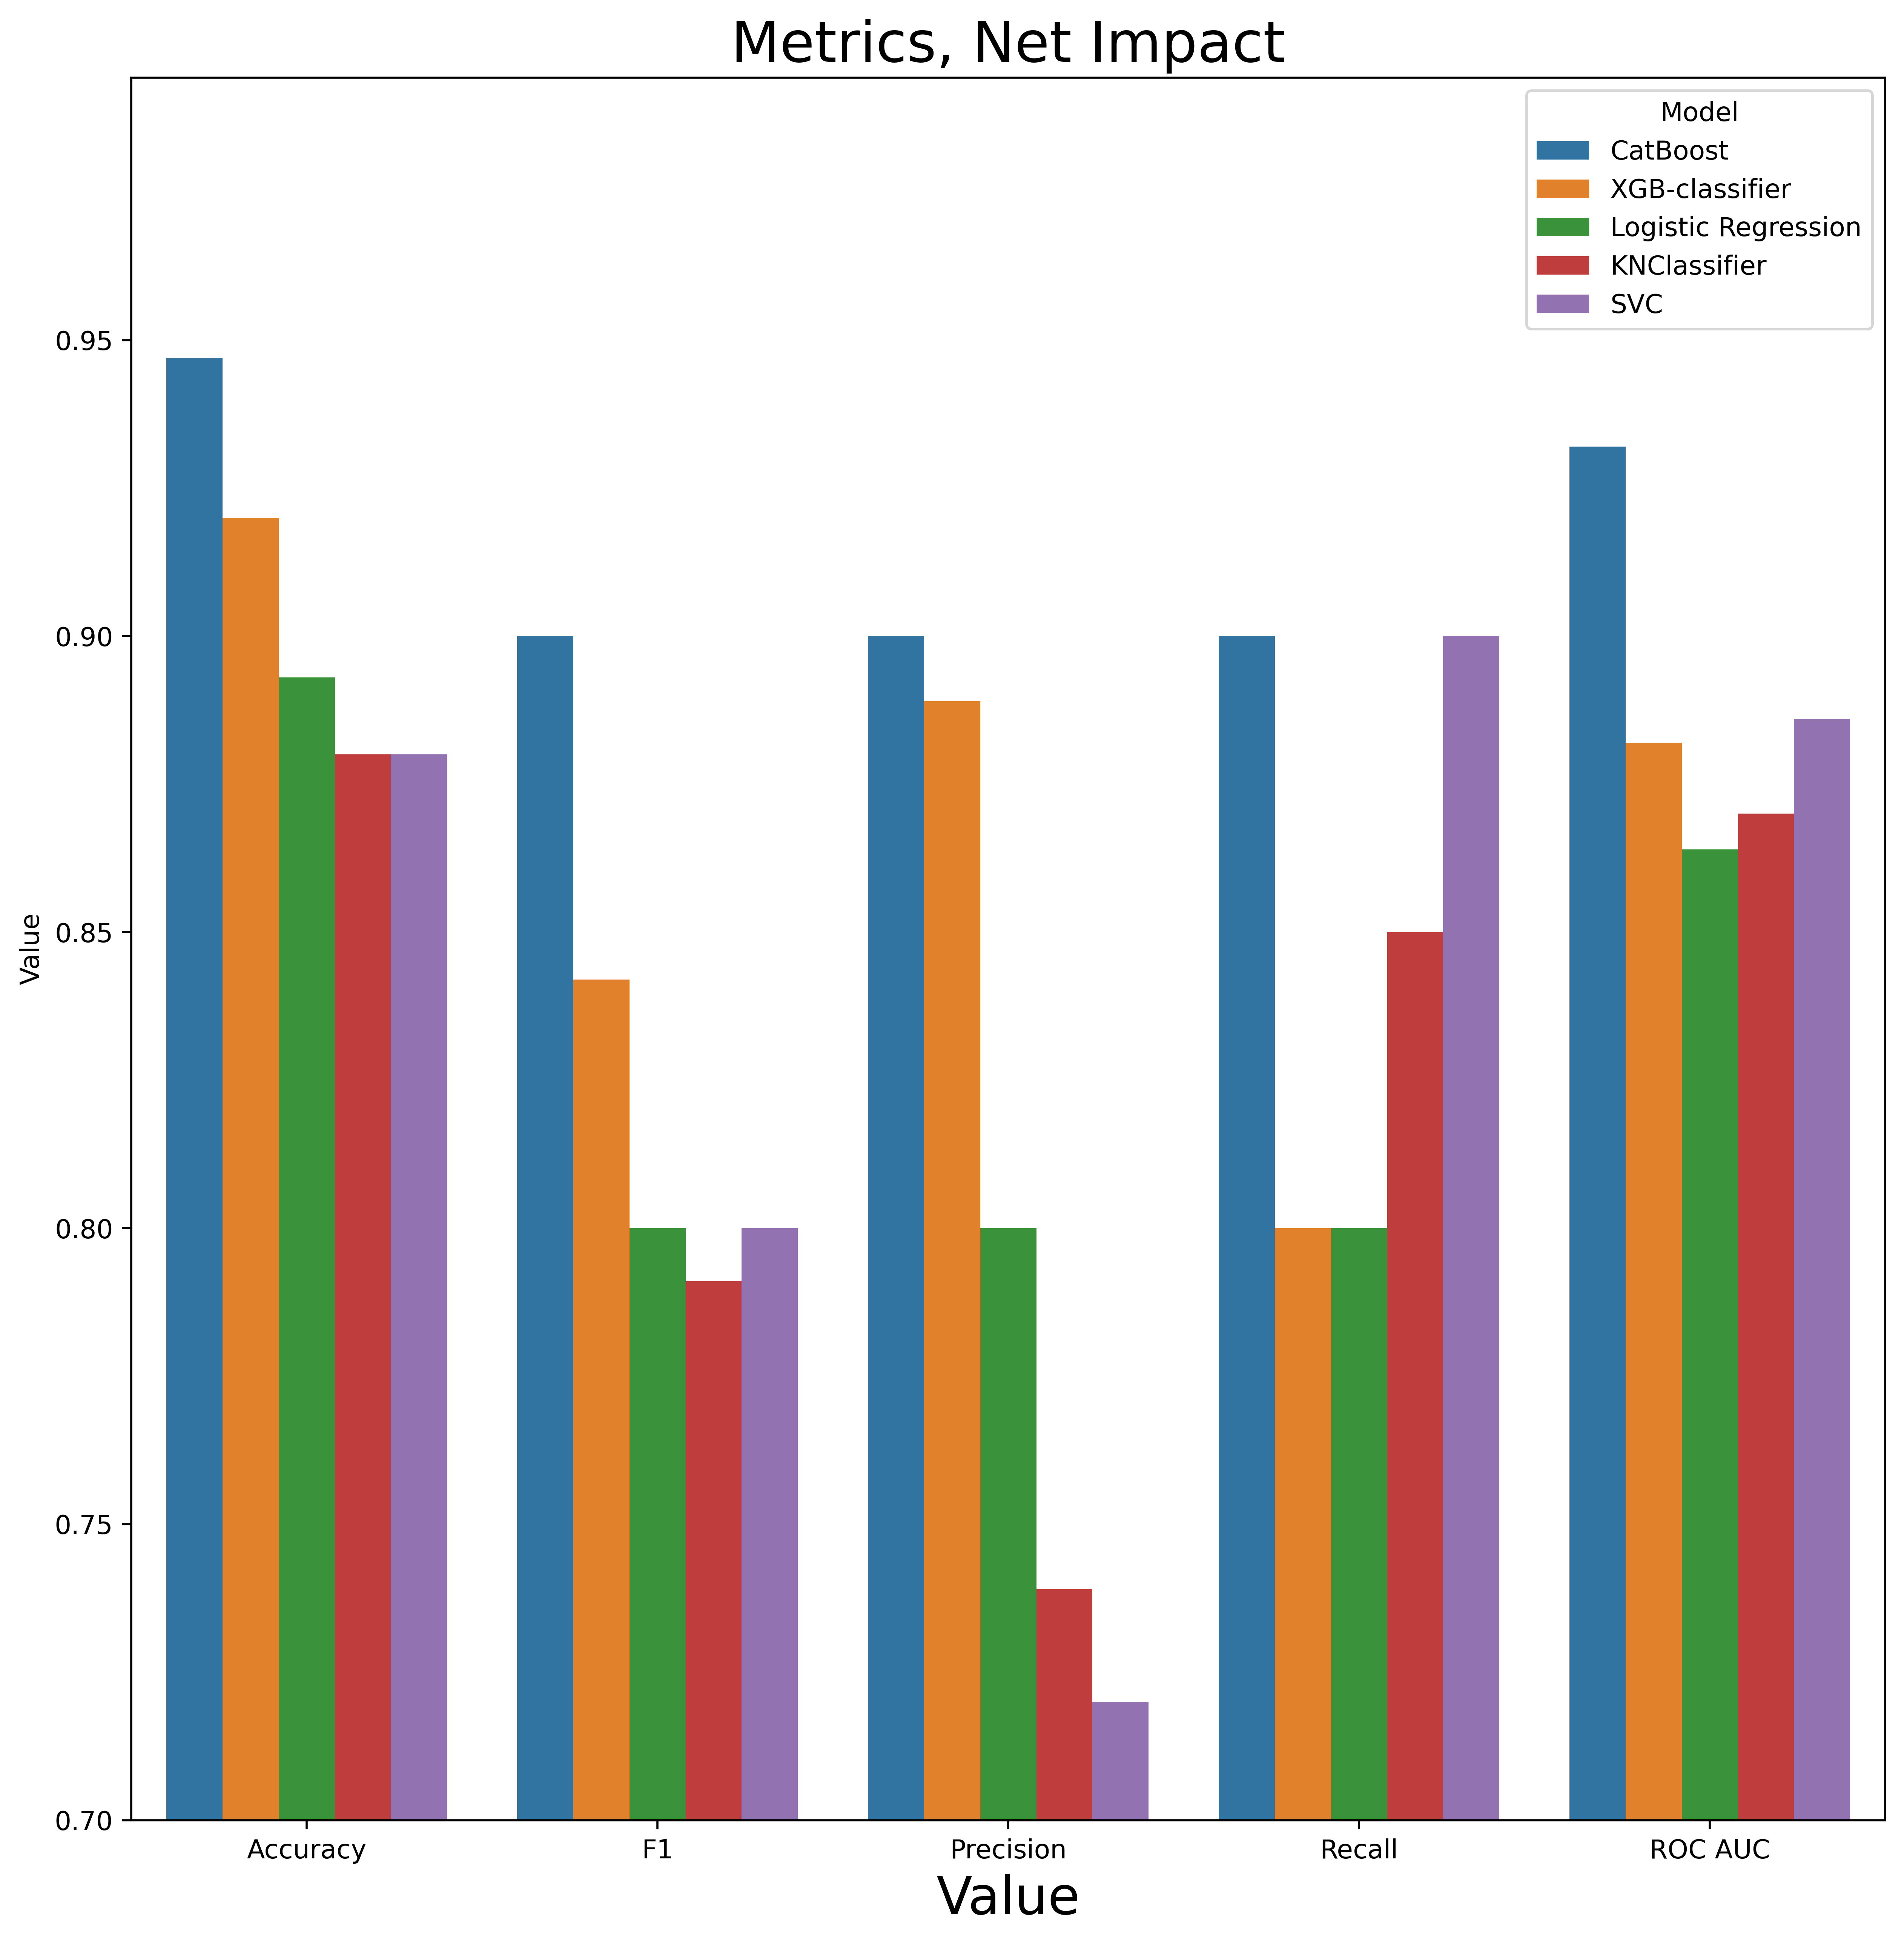

In [11]:
df_melted_net = pd.melt(df_net_impact.iloc[:, :-1], id_vars=['Model'],
        var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 12), dpi=500)
ax = sns.barplot(df_melted_net,
            x='Metric', y='Value', hue='Model')
plt.rcParams.update({'font.size': 18})
plt.title('Metrics, Net Impact')
plt.xlabel('Metric', fontsize=20)
plt.xlabel('Value', fontsize=20)
plt.ylim(0.7, plt.ylim()[1])
plt.savefig(path_visualisations / f'net_impact_metrics.pdf', bbox_inches='tight')
plt.show()

## Splashing

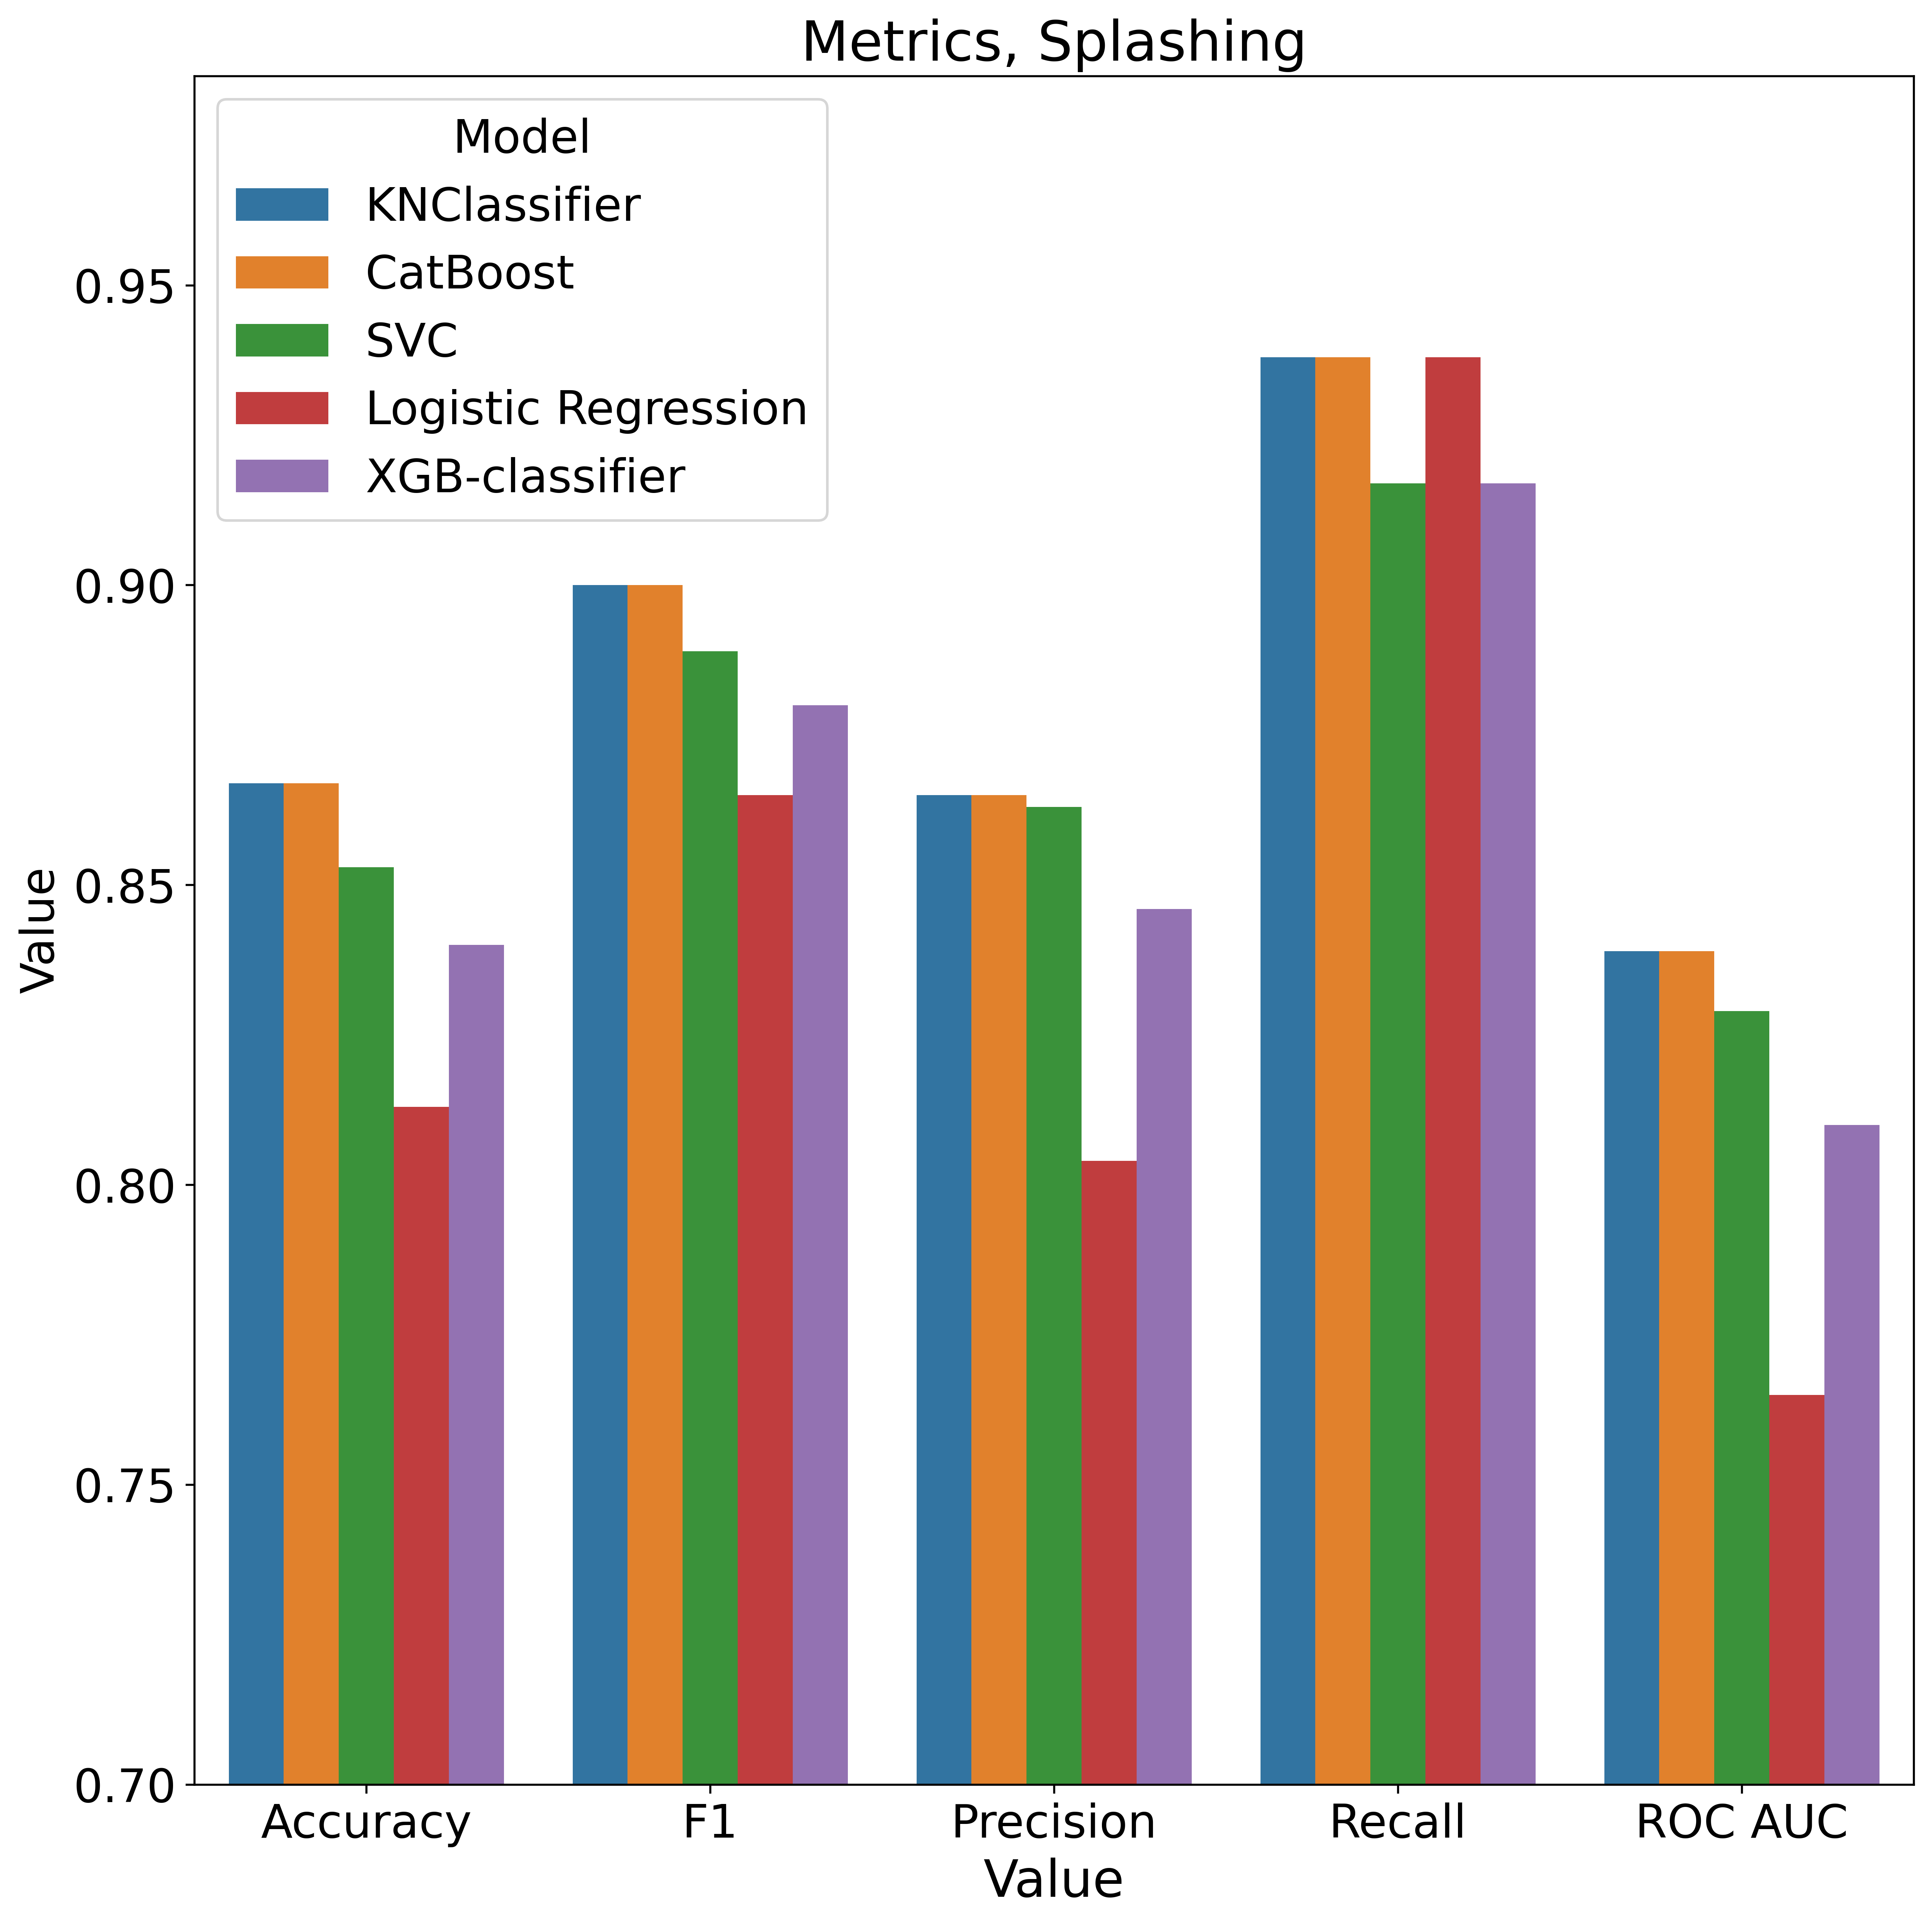

In [12]:
df_melted_splashing = pd.melt(df_spalshing.iloc[:, :-1], id_vars=['Model'],
        var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 12), dpi=500)
ax = sns.barplot(df_melted_splashing,
            x='Metric', y='Value', hue='Model')
plt.rcParams.update({'font.size': 18})
plt.title('Metrics, Splashing')
plt.xlabel('Metric', fontsize=20)
plt.xlabel('Value', fontsize=20)
plt.ylim(0.7, plt.ylim()[1])
plt.savefig(path_visualisations / f'splashing_metrics.pdf', bbox_inches='tight')
plt.show()

# Baseline comparison metrics visulisation

In [32]:
df_baseline = pd.DataFrame(
    {
    'Method':
      ['Splashing,$We^{1/2}Re^{1/4} \geq 147$',
       'Splashing, $We^{1/2}Re^{1/4} \geq 142.67$',
       'Net Impact, $We^{1/2}Re^{1/4} < 147$',
       'Net Impact, $We^{1/2}Re^{1/4} < 149.35$'],
    'Accuracy': [0.8, 0.813, 0.707, 0.747],
    'F1': [0.845361, 0.860000, 0.56, 0.641509],
    'Precision': [0.836735, 0.826923, 0.466667, 0.515152],
    'Recall': [0.854167, 0.895833, 0.7, 0.85],
    'ROC AUC': [0.778935, 0.781250, 0.704545, 0.779545]
     }).round(3)

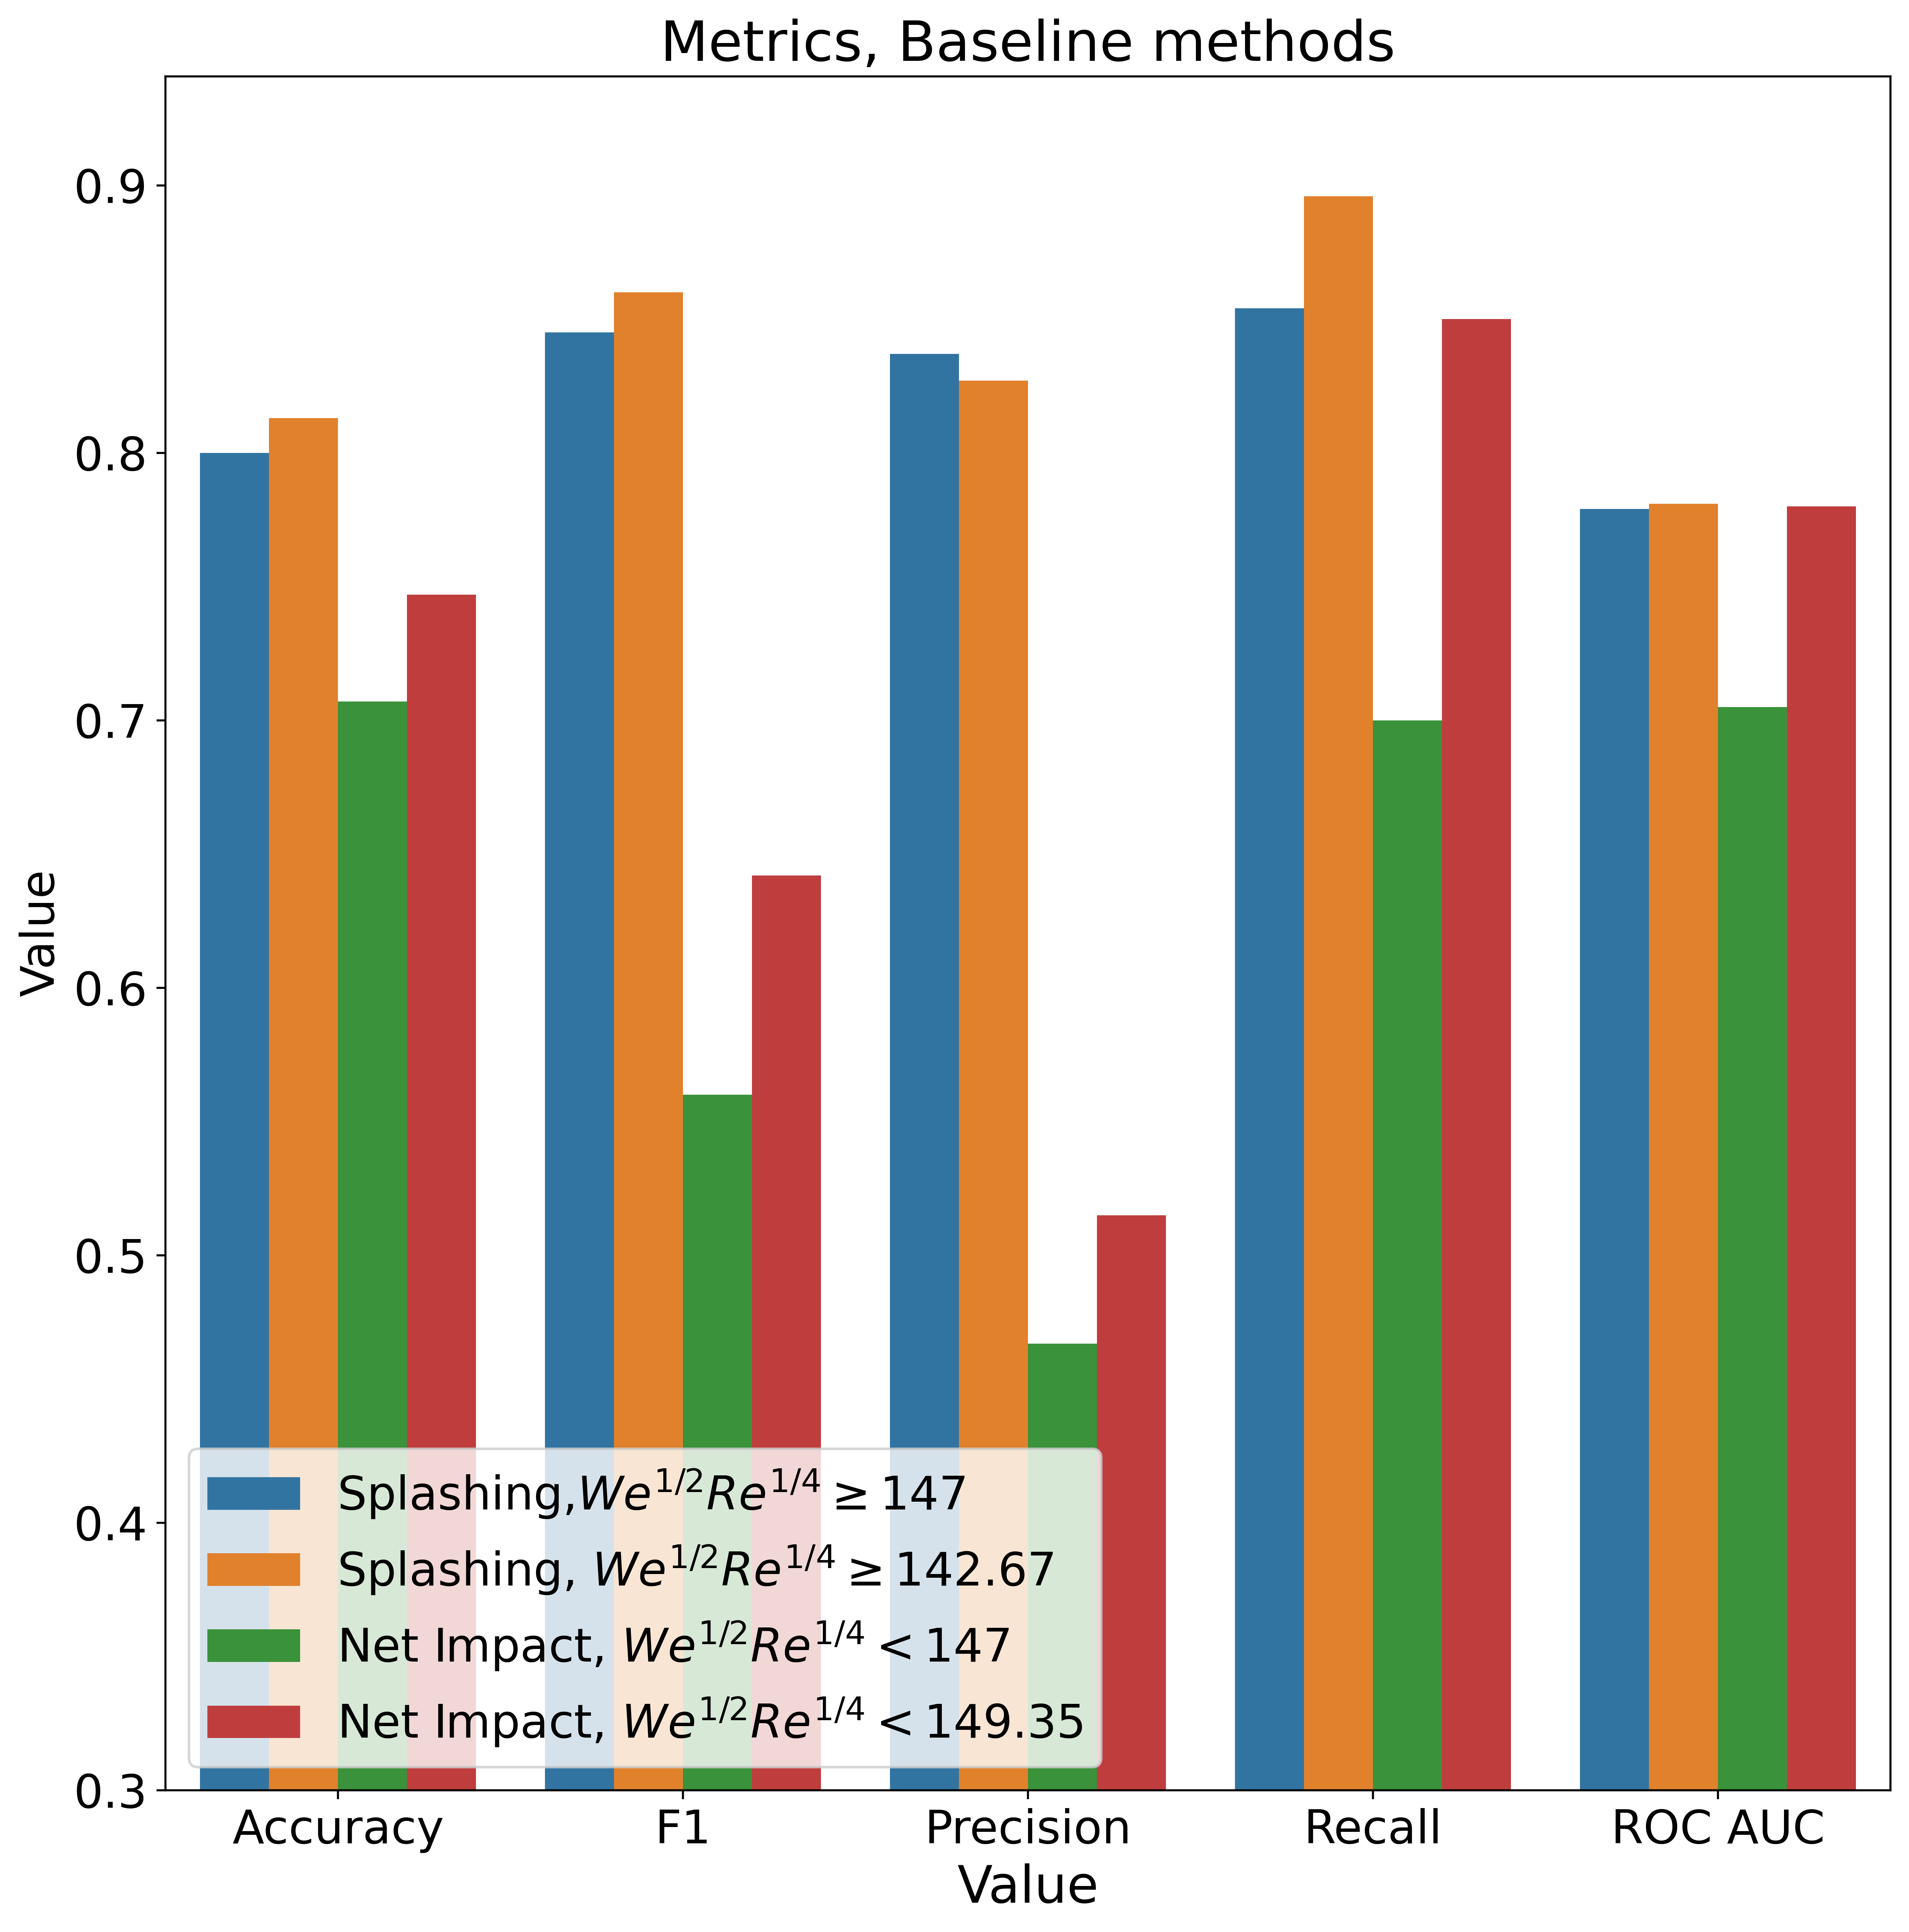

In [33]:
df_melted_base = pd.melt(df_baseline, id_vars=['Method'],
        var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 12), dpi=500)
ax = sns.barplot(df_melted_base,
            x='Metric', y='Value', hue='Method')
plt.rcParams.update({'font.size': 18})
plt.title('Metrics, Baseline methods')
plt.xlabel('Metric', fontsize=20)
plt.xlabel('Value', fontsize=20)
plt.ylim(0.3, plt.ylim()[1])

plt.legend(bbox_to_anchor=(0, 0), loc='lower left', facecolor='white')
plt.savefig(path_visualisations / f'baseline_metrics.pdf', bbox_inches='tight')
plt.show()